# Bitcoin Market Sentiment vs Trader Performance Analysis

## Objective
Analyze the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using historical trading data from Hyperliquid.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
fear_greed = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Fear & Greed Dataset Shape:", fear_greed.shape)
print("Historical Trader Dataset Shape:", trades.shape)

Fear & Greed Dataset Shape: (2644, 4)
Historical Trader Dataset Shape: (211224, 16)


## Data Understanding

In [4]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Data Cleaning and Preprocessing

In [6]:
fear_greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [7]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [8]:
fear_greed.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [9]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

## Date Conversion

In [10]:
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

In [11]:
trades['date'] = trades['Timestamp IST'].dt.date
fear_greed['date'] = fear_greed['date'].dt.date

In [12]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [13]:
trades[['Timestamp IST','date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [14]:
merged = pd.merge(
    trades,
    fear_greed[['date','classification','value']],
    on='date',
    how='left'
)

In [15]:
print(merged.shape)
merged[['date','classification','Closed PnL']].head()

(211224, 19)


,date,classification,Closed PnL
0,2024-12-02,Extreme Greed,0.0
1,2024-12-02,Extreme Greed,0.0
2,2024-12-02,Extreme Greed,0.0
3,2024-12-02,Extreme Greed,0.0
4,2024-12-02,Extreme Greed,0.0


## Exploratory Data Analysis (EDA)

In [16]:
merged['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [17]:
profit_by_sentiment = merged.groupby(
    'classification'
)['Closed PnL'].mean().sort_values(ascending=False)

print(profit_by_sentiment)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [18]:
total_profit = merged.groupby(
    'classification'
)['Closed PnL'].sum().sort_values(ascending=False)

print(total_profit)

classification
Fear             3.357155e+06
Extreme Greed    2.715171e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Extreme Fear     7.391102e+05
Name: Closed PnL, dtype: float64


In [19]:
trade_size = merged.groupby(
    'classification'
)['Size USD'].mean().sort_values(ascending=False)

print(trade_size)

classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64


In [20]:
fee_analysis = merged.groupby(
    'classification'
)['Fee'].mean().sort_values(ascending=False)

print(fee_analysis)

classification
Fear             1.495172
Greed            1.254372
Extreme Fear     1.116291
Neutral          1.044798
Extreme Greed    0.675902
Name: Fee, dtype: float64


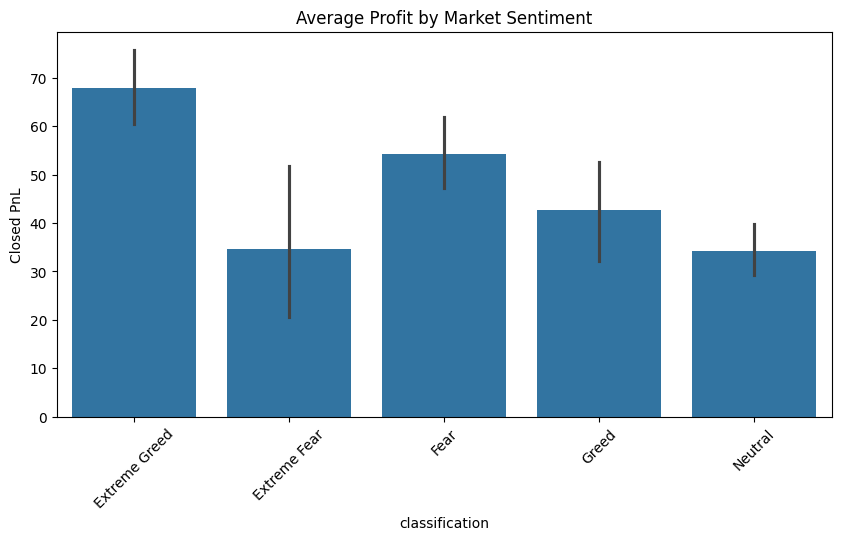

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title("Average Profit by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

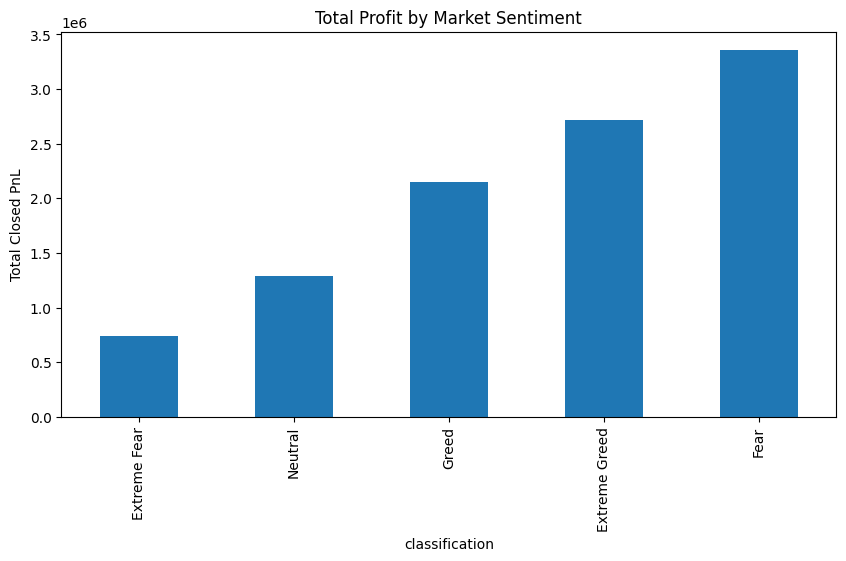

In [22]:
plt.figure(figsize=(10,5))

merged.groupby('classification')['Closed PnL'].sum().sort_values().plot(kind='bar')

plt.title('Total Profit by Market Sentiment')
plt.ylabel('Total Closed PnL')
plt.show()

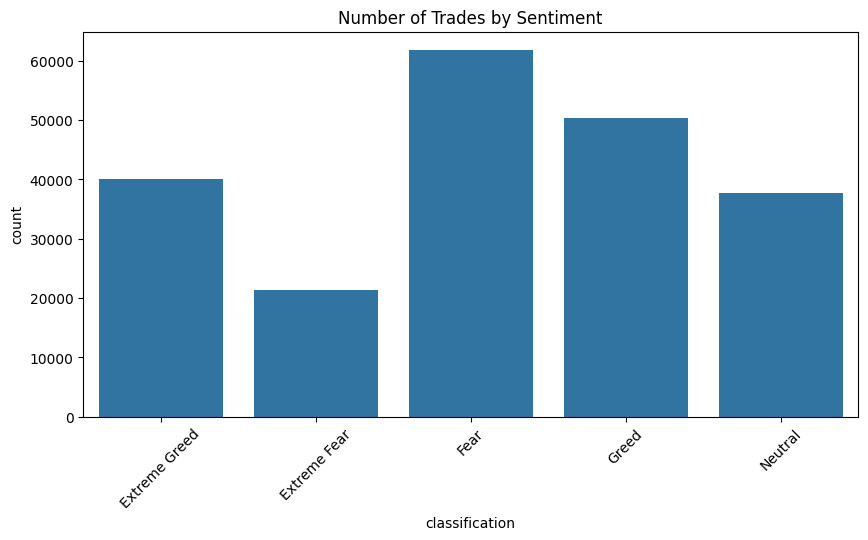

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=merged,
    x='classification'
)

plt.title('Number of Trades by Sentiment')
plt.xticks(rotation=45)
plt.show()

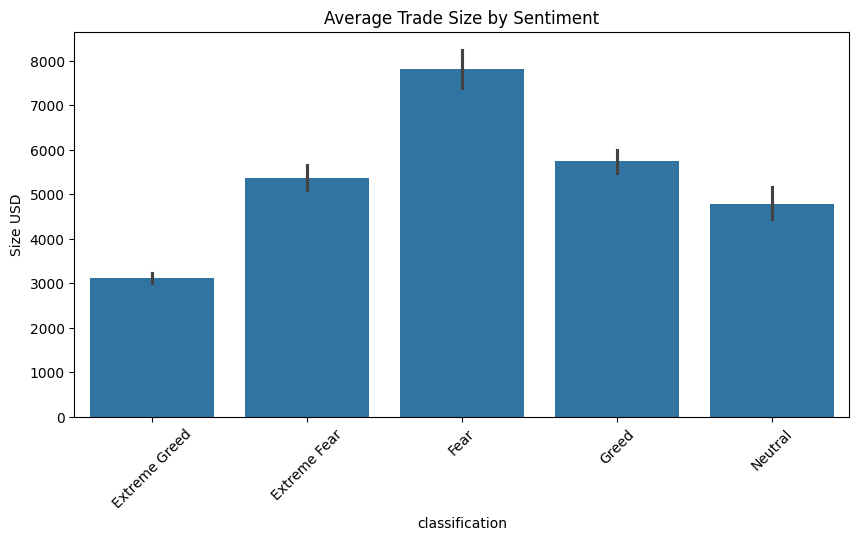

In [24]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=merged,
    x='classification',
    y='Size USD'
)

plt.title('Average Trade Size by Sentiment')
plt.xticks(rotation=45)
plt.show()

## Key Findings

### Finding 1
Average trader profitability was highest during Extreme Greed periods.

### Finding 2
Extreme Fear periods showed the lowest average profitability.

### Finding 3
Market sentiment appears to influence trader performance significantly.

### Finding 4
Fear and Extreme Greed periods generated higher average returns than Neutral conditions.

In [25]:
winning_trades = merged[merged['Closed PnL'] > 0]

winning_trades.groupby(
    'classification'
)['Closed PnL'].count().sort_values(ascending=False)

classification
Fear             26019
Greed            19358
Extreme Greed    18594
Neutral          14961
Extreme Fear      7931
Name: Closed PnL, dtype: int64

In [26]:
losing_trades = merged[merged['Closed PnL'] < 0]

losing_trades.groupby(
    'classification'
)['Closed PnL'].count().sort_values(ascending=False)

classification
Greed            5818
Fear             3789
Neutral          3198
Extreme Fear     2475
Extreme Greed    2259
Name: Closed PnL, dtype: int64

In [27]:
win_loss = merged.groupby('classification').apply(
    lambda x: (x['Closed PnL'] > 0).sum() / ((x['Closed PnL'] > 0).sum() + (x['Closed PnL'] < 0).sum()) * 100
)

print(win_loss.sort_values(ascending=False))

classification
Extreme Greed    89.167026
Fear             87.288647
Neutral          82.388898
Greed            76.890690
Extreme Fear     76.215645
dtype: float64


C:\Users\praya\AppData\Local\Temp\ipykernel_3616\3136523702.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_loss = merged.groupby('classification').apply(


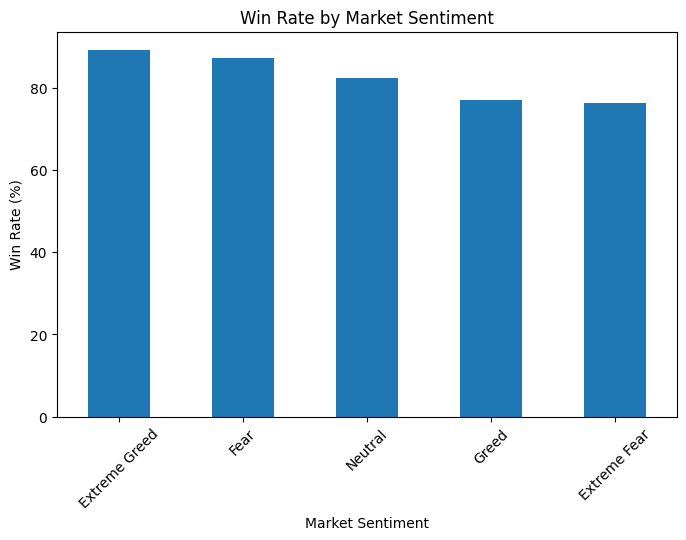

In [31]:
plt.figure(figsize=(8,5))

win_loss.sort_values(ascending=False).plot(kind='bar')

plt.title('Win Rate by Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.xlabel('Market Sentiment')
plt.xticks(rotation=45)

plt.show()

## Key Findings

### Finding 1
Traders achieved the highest average profit during Extreme Greed market conditions.

### Finding 2
Fear periods generated the highest number of profitable trades (26,019 winning trades).

### Finding 3
Greed periods recorded the highest number of losing trades (5,818 losing trades).

### Finding 4
Extreme Fear periods exhibited the lowest average profitability, indicating challenging market conditions for traders.

### Finding 5
Market sentiment has a noticeable impact on trader performance, suggesting that emotional market states influence trading outcomes.

In [28]:
merged.groupby('classification')['Size USD'].mean().sort_values(ascending=False)

classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64

In [29]:
merged.groupby('classification')['Fee'].mean().sort_values(ascending=False)

classification
Fear             1.495172
Greed            1.254372
Extreme Fear     1.116291
Neutral          1.044798
Extreme Greed    0.675902
Name: Fee, dtype: float64

# Key Findings

### 1. Profitability and Sentiment
Extreme Greed market conditions produced the highest average trader profitability, while Extreme Fear generated the lowest average profitability.

### 2. Win Rate Analysis
Extreme Greed achieved the highest win rate (89.17%), whereas Extreme Fear recorded the lowest win rate (76.22%).

### 3. Fear Market Opportunities
Fear periods generated the highest number of profitable trades, indicating that traders may capitalize on market pullbacks and temporary price declines.

### 4. Trade Size Analysis
The largest average trade sizes were observed during Fear periods, suggesting increased trader confidence in buying opportunities during uncertain market conditions.

### 5. Fee Analysis
Trading fees were highest during Fear periods, reflecting larger average position sizes and increased trading activity.

### 6. Market Sentiment Impact
The results demonstrate a clear relationship between market sentiment and trading performance, indicating that sentiment can be a useful factor in evaluating trading strategies.

# Conclusion

This study analyzed the relationship between Bitcoin market sentiment and trader performance using the Fear & Greed Index and historical trading data.

The results indicate that market sentiment has a measurable influence on trading outcomes. Traders generally performed best during Extreme Greed conditions, while Extreme Fear periods were associated with lower profitability and win rates. Fear periods also revealed interesting opportunities, with traders taking larger positions and generating a high number of profitable trades.

Overall, sentiment indicators can provide valuable context for understanding market behavior and improving trading decision-making.

# Recommendations

- Incorporate sentiment indicators into trading strategies.
- Exercise caution during Extreme Fear periods.
- Monitor market sentiment alongside technical indicators.
- Further research can include leverage analysis and coin-specific sentiment effects.

# References

1. Bitcoin Fear & Greed Index Dataset
2. Hyperliquid Historical Trader Dataset
3. Python Libraries: Pandas, NumPy, Matplotlib, Seaborn